# **Experiment Notebook**



In [1]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [3]:
# <Student to fill this section>

# import packages required for the assignment

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from lime.lime_tabular import LimeTabularExplainer



---
## A. Project Description


In [4]:
# <Student to fill this section>
student_name = "Ashley Wang"
student_id = "14121545"
group_id = "Group24"

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

In [7]:
# Do not modify this code
print_tile(size="h1", key='group_id', value=group_id)

---
## B. Business Understanding

In [8]:
# <Student to fill this section>
business_use_case_description = """
The goal of this project is to predict whether a basketball player will be drafted into the NBA.
From a business perspective, such a model can support analysts, scouts, and fans by providing a probability 
score for each player. This enables ranking and comparison of players, helps commentators generate insights, 
and supports discussions around draft decisions. The key measure of success is a model that achieves strong 
AUROC performance, ensuring reliable differentiation between likely and unlikely draft picks.
"""

In [9]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [10]:
# <Student to fill this section>
business_objectives = """
Accurate results will allow analysts, scouts, and fans to better understand which players have a 
higher chance of being drafted. This could support media commentary, scouting reports, and fan engagement.  

If the predictions are incorrect, the impact is limited to misinforming discussions and rankings. 
Since this project is for learning and competition purposes, there is no direct financial loss, 
but poor results may reduce the credibility of the model and its usefulness in supporting analysis.
"""

In [11]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [12]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
The predictions will mainly be used to support decisions around which college players are most likely 
to be drafted. General managers and scouts will use the results to rank and compare players, helping them 
decide who deserves more attention or resources. The analytics team will focus on checking the reliability 
of the model and making sure the outputs are consistent, while coaches might look at the predictions to 
consider how certain players could fit into their team. Players themselves are also impacted because the 
scores may influence how much recognition they get, and fans or owners are indirectly affected through 
the quality of the team roster. Overall, the use of predictions is to provide guidance and reduce uncertainty, 
with the impact extending from the decision-makers inside the organisation to the players and the wider 
basketball community.
"""

In [13]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [14]:
# <Student to fill this section>

# Set the data directory 
data_path = Path("uts-36120-25-sp") / "raw"

# Load train, test, and sample submission files

train = pd.read_csv(data_path / "train.csv", encoding="latin1")
test = pd.read_csv(data_path / "test.csv", encoding="latin1")
sample_submission = pd.read_csv(data_path / "sample_submission.csv", encoding="latin1")
metadata = pd.read_csv(data_path / "metadata.csv", encoding="latin1")

print("Train shape:", train.shape)   
print("Test shape:", test.shape)     
print("Sample submission shape:", sample_submission.shape)  
print("Metadata shape:", metadata.shape) 

display(train.head())
display(metadata.head())

Train shape: (14774, 62)
Test shape: (1297, 61)
Sample submission shape: (1297, 2)
Metadata shape: (62, 3)


,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id,drafted
0,Pacific,BW,26,52.6,111.8,19.3,61.8,64.93,1.1,7.5,...,-1.34201,0.2308,1.5769,1.8077,2.2308,0.6538,0.0769,9.6538,681edf6e-41cb-4fd1-ba91-da573e063fbc,0.0
1,Mississippi,SEC,2,0.8,63.6,29.6,33.3,33.33,0.0,21.5,...,-5.42104,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,2.0000,3542dcb7-19ad-47f2-8b3a-eb79eb3ec4c4,0.0
2,Stephen F. Austin,Slnd,4,0.6,61.4,21.7,50.0,50.00,0.0,0.0,...,6.46650,0.0000,0.0000,0.0000,0.0000,0.2500,0.0000,0.5000,ca0d8700-807d-4fce-a7a9-63922d1981e6,0.0
3,Virginia,ACC,28,59.2,88.2,21.7,46.2,47.25,1.5,9.7,...,1.45913,0.3214,2.0357,2.3571,3.0000,1.2857,0.0714,7.7500,01285c6b-bc71-4fa8-941a-28cf3976a117,0.0
4,Elon,SC,21,13.7,47.5,15.0,26.2,26.20,5.8,2.3,...,-3.75694,0.3810,0.1429,0.5238,0.4286,0.1905,0.0000,0.5714,a962c41c-55ff-461e-8585-db32e4fa0580,0.0


,feature,name,description
0,1,team,Name of team
1,2,conf,Name of conference
2,3,GP,Games played
3,4,Min_per,Player's percentage of available team minutes ...
4,5,ORtg,ORtg - Offensive Rating (available since the 1...


### C.2 Define Target variable

In [15]:
# <Student to fill this section>

# Define target variable and split features from target 

target_column = "drafted"                
X_train = train.drop(columns=[target_column])  
y_train = train[target_column]                


print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

# Check class distribution
print("\nClass distribution:")
print(y_train.value_counts())
print("\nNormalized distribution:")
print(y_train.value_counts(normalize=True))


X_train shape: (14774, 61)
y_train shape: (14774,)

Class distribution:
drafted
0.0    14656
1.0      118
Name: count, dtype: int64

Normalized distribution:
drafted
0.0    0.992013
1.0    0.007987
Name: proportion, dtype: float64


In [16]:
# <Student to fill this section>
target_definition_explanations = """
The target variable is drafted, which shows whether a player was selected in the NBA draft (1 = drafted, 0 = not drafted). 
We will train models that give probabilities, so we can compare players not only by category but also by how likely they are to be drafted.
"""

In [17]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [18]:
# <Student to fill this section>

target_name = "drafted"

### C.4 Explore Target variable

In [19]:
# <Student to fill this section>
# Count of target variable
counts = train[target_name].value_counts()
proportions = train[target_name].value_counts(normalize=True)

print("Class counts:\n", counts)
print("\nClass proportions:\n", proportions)



Class counts:
 drafted
0.0    14656
1.0      118
Name: count, dtype: int64

Class proportions:
 drafted
0.0    0.992013
1.0    0.007987
Name: proportion, dtype: float64


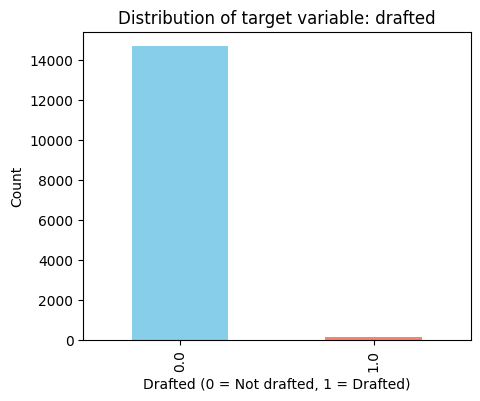

In [20]:
# Visualize target distribution
plt.figure(figsize=(5,4))
counts.plot(kind="bar", color=["skyblue", "salmon"])
plt.title("Distribution of target variable: drafted")
plt.xlabel("Drafted (0 = Not drafted, 1 = Drafted)")
plt.ylabel("Count")
plt.show()

In [21]:
# <Student to fill this section>
target_distribution_explanations = """
The target variable drafted is extremely imbalanced. Out of 14,774 players, 14,656 were not drafted (≈99.2%), while only 118 were drafted (≈0.8%). This shows that being drafted is a rare event in the dataset. Such imbalance creates challenges for model training. A simple model that always predicts “not drafted” could already reach very high accuracy, but it would fail to identify the few players who actually got drafted. Because of this, accuracy is not a suitable metric. AUC-ROC is more appropriate since it measures the model’s ability to separate classes under imbalance. In addition, other complementary metrics are also useful. AUPRC focuses on performance with the minority class, while Precision, Recall, and the F1-score provide more insight into the trade-off between correctly identifying drafted players and avoiding false alarms. These metrics together give a clearer and more reliable evaluation of model performance under severe imbalance.
"""

In [22]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest - Points per game(pts)

In [23]:
# <Student to fill this section>

# Explore feature of interest: pts 

feature_of_interest_pts = "pts"

# Summary statistics
print(train[feature_of_interest_pts].describe())

count    14773.000000
mean         3.662676
std          3.623175
min          0.000000
25%          1.000000
50%          2.448300
75%          5.363600
max         27.375000
Name: pts, dtype: float64


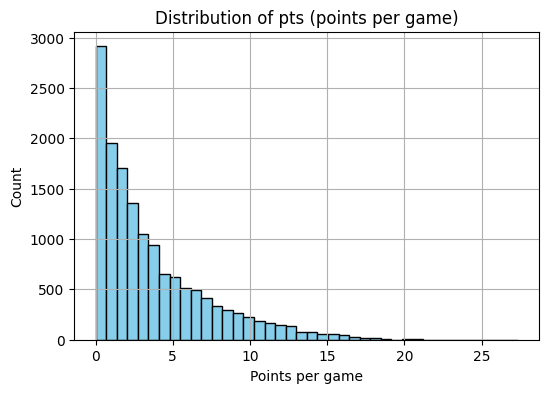

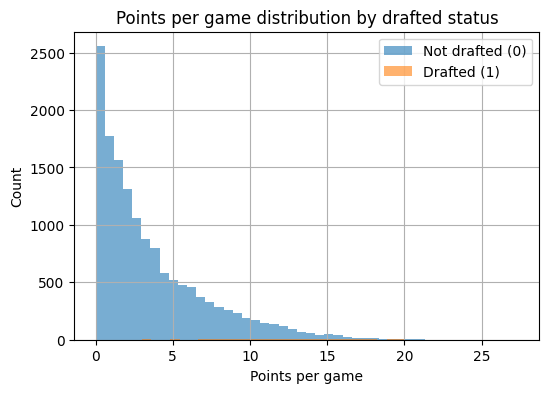

In [24]:
# Distribution
plt.figure(figsize=(6,4))
train[feature_of_interest_pts].hist(bins=40, color="skyblue", edgecolor="black")
plt.title("Distribution of pts (points per game)")
plt.xlabel("Points per game")
plt.ylabel("Count")
plt.show()

# Distribution by drafted status
plt.figure(figsize=(6,4))
train.groupby("drafted")[feature_of_interest_pts].hist(bins=40, alpha=0.6)
plt.title("Points per game distribution by drafted status")
plt.xlabel("Points per game")
plt.ylabel("Count")
plt.legend(["Not drafted (0)", "Drafted (1)"])
plt.show()

In [25]:
# <Student to fill this section>
feature_1_insights = """
The distribution of points per game is highly skewed, with most players averaging between 0 and 5 points, while only a few achieve very high scoring levels. When separated by drafted status, it becomes clear that drafted players generally have higher scoring averages compared to those not drafted. This suggests that scoring ability is an important factor in draft decisions. However, there are some limitations. First, points are strongly influenced by playing time, so players with more minutes naturally score more, which may bias the feature. Second, focusing only on scoring ignores other important contributions such as defense, rebounding, or efficiency. Finally, a small number of outliers with extremely high averages could dominate the analysis if not treated properly."""

In [26]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest - minutes played (mp)

In [27]:
# <Student to fill this section>

# Explore feature of interest: minutes played (mp)

feature_of_interest_mp = "mp" 

print(train[feature_of_interest_mp].describe())

count    14773.000000
mean        12.276197
std          8.979124
min          0.000000
25%          4.642900
50%         10.250000
75%         18.500000
max         50.000000
Name: mp, dtype: float64


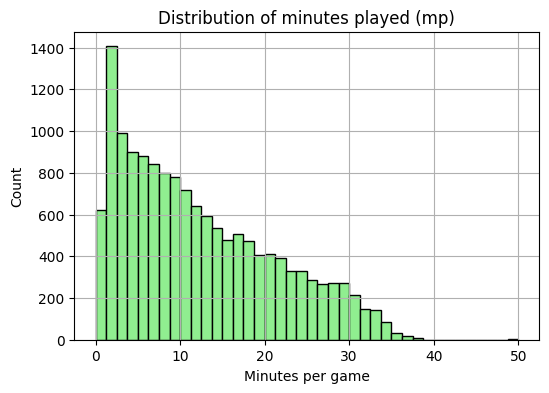

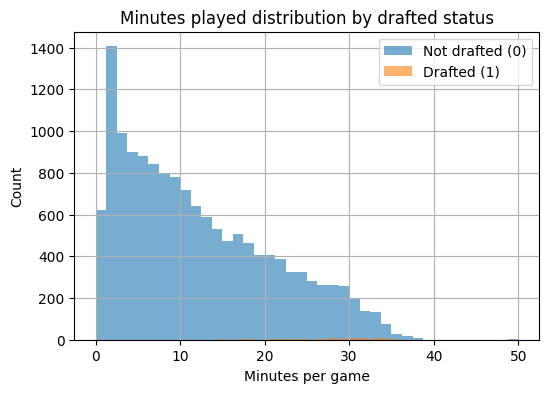

In [28]:
# Distribution
plt.figure(figsize=(6,4))
train[feature_of_interest_mp].hist(bins=40, color="lightgreen", edgecolor="black")
plt.title("Distribution of minutes played (mp)")
plt.xlabel("Minutes per game")
plt.ylabel("Count")
plt.show()

# Distribution by drafted status
plt.figure(figsize=(6,4))
train.groupby("drafted")[feature_of_interest_mp].hist(bins=40, alpha=0.6)
plt.title("Minutes played distribution by drafted status")
plt.xlabel("Minutes per game")
plt.ylabel("Count")
plt.legend(["Not drafted (0)", "Drafted (1)"])
plt.show()


In [29]:
# <Student to fill this section>
feature_2_insights = """
The feature minutes played per game shows that most players receive limited playing time, with a median of just 10.25 minutes. The distribution is right-skewed: a large number of players play fewer than 10 minutes, while only a small group consistently play more than 30 minutes, with the maximum reaching 50 minutes. When separated by drafted status, drafted players tend to have more playing time, which suggests that consistent minutes on court reflect both higher skill and trust from coaches. However, this feature also has limitations. Playing time may not only reflect talent, but also depend on team rotations, injuries, or specific coaching strategies. As a result, some skilled players may appear undervalued in the data if they had fewer opportunities, and extreme outliers with unusually high playing time could bias the analysis.
"""

In [30]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.6 Explore Feature of Interest - Effective Field Goal Percentage (eFG)


In [31]:
# <Student to fill this section>

# Explore feature of interest: eFG

feature_of_interest_eFG = "eFG"

print(train[feature_of_interest_eFG].describe())

count    14774.000000
mean        41.507628
std         20.610900
min          0.000000
25%         34.800000
50%         44.900000
75%         51.400000
max        150.000000
Name: eFG, dtype: float64


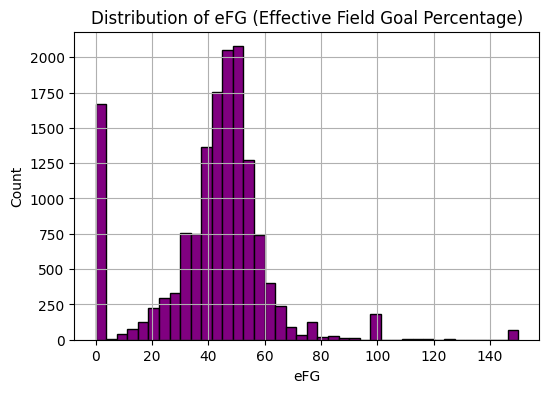

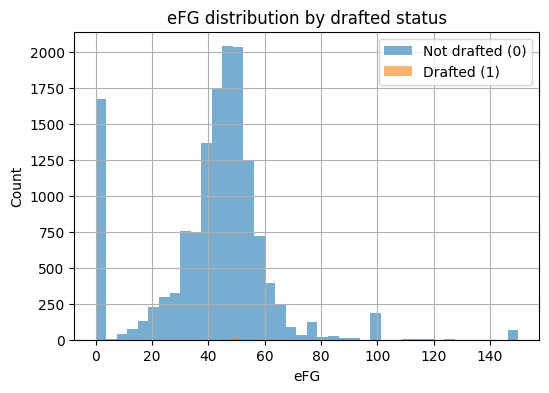

In [32]:
# Distribution
plt.figure(figsize=(6,4))
train[feature_of_interest_eFG].hist(bins=40, color="purple", edgecolor="black")
plt.title("Distribution of eFG (Effective Field Goal Percentage)")
plt.xlabel("eFG")
plt.ylabel("Count")
plt.show()

# Distribution by drafted status
plt.figure(figsize=(6,4))
train.groupby("drafted")[feature_of_interest_eFG].hist(bins=40, alpha=0.6)
plt.title("eFG distribution by drafted status")
plt.xlabel("eFG")
plt.ylabel("Count")
plt.legend(["Not drafted (0)", "Drafted (1)"])
plt.show()


In [33]:
# <Student to fill this section>
feature_3_insights = """
The feature effective field goal percentage reflects a player’s shooting efficiency adjusted for the higher value of three-point shots. The distribution is centered around 40–50%, which matches typical basketball shooting patterns, but also shows some outliers far above 100%. Drafted players generally appear in the higher end of the distribution, which suggests that more efficient shooters are more likely to be drafted. However, there are several limitations. Some players record an eFG of 0, likely due to missing all of their attempts, while extreme values such as 150% occur when players have very few attempts, making the percentage unreliable. Furthermore, this metric may depend heavily on a player’s role and position.
For example, centers tend to have higher eFG due to close-range shots, while guards often attempt more three-pointers with lower efficiency. As a result, while eFG is an important indicator of efficiency, it should be interpreted alongside playing time, volume of attempts, and role on the team.
"""

In [34]:
# Do not modify this code
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

### C.n Explore Feature of Interest - True shooting percentage (TS_per)

> You can add more cells related to other feeatures in this section

In [35]:
# Explore feature of interest: TS_per (true shooting percentage)

feature_of_interest_ts = "TS_per"

# Summary
print(train[feature_of_interest_ts].describe())

count    14774.000000
mean        44.566821
std         19.622173
min          0.000000
25%         38.820000
50%         48.285000
75%         54.090000
max        150.000000
Name: TS_per, dtype: float64


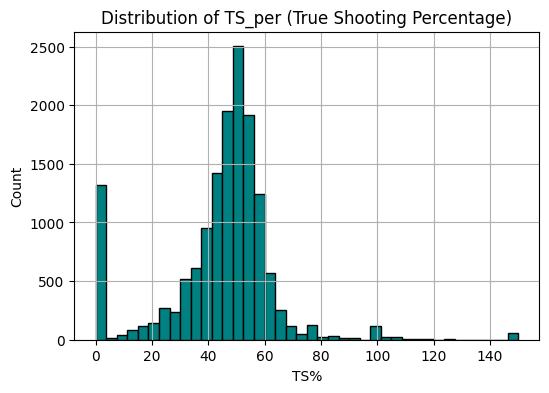

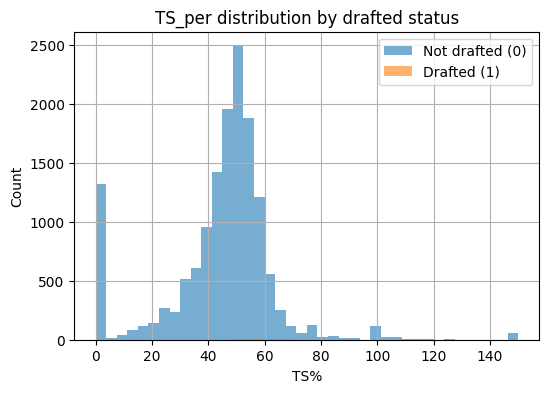

In [36]:
# Distribution
plt.figure(figsize=(6,4))
train[feature_of_interest_ts].hist(bins=40, color="teal", edgecolor="black")
plt.title("Distribution of TS_per (True Shooting Percentage)")
plt.xlabel("TS%")
plt.ylabel("Count")
plt.show()

# Distribution by drafted status
plt.figure(figsize=(6,4))
train.groupby("drafted")[feature_of_interest_ts].hist(bins=40, alpha=0.6)
plt.title("TS_per distribution by drafted status")
plt.xlabel("TS%")
plt.ylabel("Count")
plt.legend(["Not drafted (0)", "Drafted (1)"])
plt.show()

In [37]:
# <Student to fill this section>
feature_n_insights = """
The feature True shooting percentage is a comprehensive measure of efficiency that accounts for field goals, three-pointers, and free throws. The distribution is centered between 40% and 55%, consistent with typical basketball performance. Drafted players tend to appear in the higher range of the distribution, which suggests that more efficient scorers are favored in draft decisions. However, the feature also presents some limitations. A group of players show 0% TS, which indicates either missed all attempts or extremely low volume, and some unrealistic values above 100% appear due to very few attempts. In addition, shooting efficiency varies by role and position; for example, perimeter players often have lower TS% than big men who take higher-percentage shots near the rim. Therefore, while TS_per is a useful indicator of overall efficiency, it must be interpreted with caution and in combination with usage and playing time.
"""

In [38]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

---
## D. Feature Selection


### D.1 Approach - Correlation + Multicollinearity Removal


In [39]:
# <Student to fill this section>

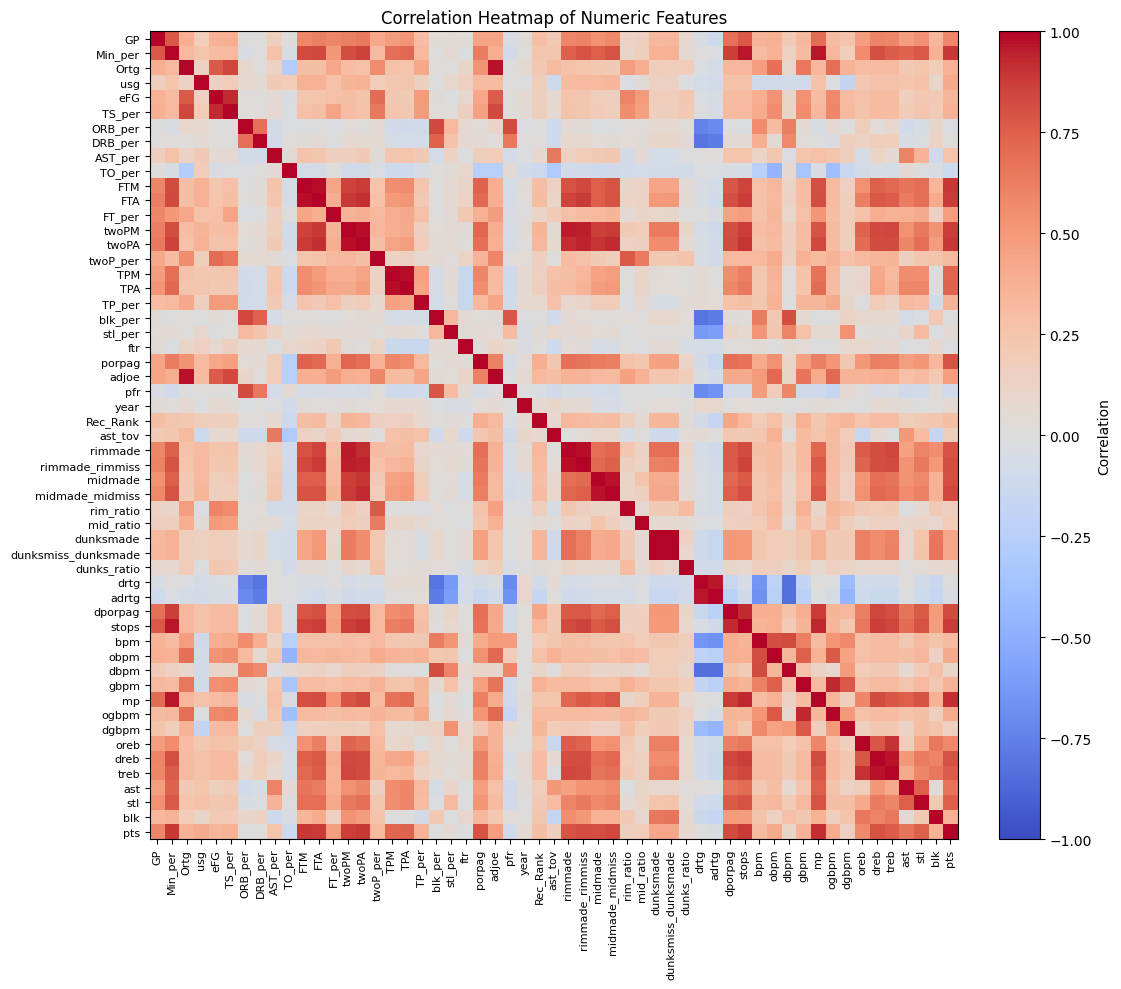

In [40]:
# 1) Drop target and obvious identifiers
id_like_cols = ["player_id"]
X_all = train.drop(columns=[c for c in [target_name] + id_like_cols if c in train.columns]).copy()
y_all = train[target_name].astype(int).copy()

# 2) Only numeric columns for analysis
num_cols = X_all.select_dtypes(include=[np.number]).columns.tolist()
X_num = X_all[num_cols]

# 3) Correlation matrix
corr = X_num.corr(numeric_only=True)

# 4) Correlation heatmap 
plt.figure(figsize=(12, 10))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Correlation")
plt.title("Correlation Heatmap of Numeric Features")
plt.xticks(range(len(num_cols)), num_cols, rotation=90, fontsize=8)
plt.yticks(range(len(num_cols)), num_cols, fontsize=8)
plt.tight_layout()
plt.show()


In [41]:
# 5) Remove highly correlated features using upper triangle with a threshold 0.85  (above 0.85 considered highly collinear and do not add significant info)

threshold = 0.85  
to_drop_corr = set()
cols = corr.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if np.abs(corr.iloc[i, j]) > threshold:
            to_drop_corr.add(cols[j])

# 6) Drop single-value columns with no information
single_value_cols = [c for c in X_all.columns if X_all[c].nunique(dropna=True) <= 1]

# 7) Columns to drop
to_drop_total = sorted(set(to_drop_corr).union(single_value_cols))

# 8) Final kept features 
selected_features_corr = [c for c in X_all.columns if c not in to_drop_total]

print(f"[Approach 1] Original features: {X_all.shape[1]}")
print(f"[Approach 1] Kept features after drop: {len(selected_features_corr)}")

[Approach 1] Original features: 60
[Approach 1] Kept features after drop: 39


In [42]:
# <Student to fill this section>
feature_selection_1_insights = """
In this approach, I analyzed pairwise correlations among numeric features to identify redundancy and multicollinearity. Features with absolute correlation coefficients above 0.85 were considered highly redundant. In each correlated pair, I dropped one of the features to reduce overlap and improve model stability. In addition, constant features with only one unique value were also removed because they carry no predictive information.

The heatmap reveals several groups of strongly correlated features, such as shooting efficiency metrics (eFG, TS_per, twoP_per), and rebounding-related variables.
After applying the correlation threshold and removing constant columns, the feature set was reduced from 60 original features to 39 selected features.
This selection helps ensure that the final dataset contains fewer but more independent features, which improves interpretability and reduces the risk of unstable parameter estimates in models such as logistic regression.
"""

In [43]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach - Mutual Information


In [44]:
# 1) Drop target and obvious identifiers
id_like_cols = ["player_id"]
X_all = train.drop(columns=[c for c in [target_name] + id_like_cols if c in train.columns]).copy()
y_all = train[target_name].astype(int).copy()

# 2) Separate numeric and categorical
num_cols = X_all.select_dtypes(include=[np.number]).columns.tolist()
obj_cols = X_all.select_dtypes(include=["object"]).columns.tolist()

X_num = X_all[num_cols].copy()
X_obj = X_all[obj_cols].copy()

X_obj_enc = pd.DataFrame(index=X_obj.index)
for c in obj_cols:
    codes, uniques = pd.factorize(X_obj[c], sort=True)
    codes = np.where(pd.isna(X_obj[c].values), -1, codes)
    X_obj_enc[c] = codes

# 3) Combine numeric and categorical; impute numeric NaNs with median
X_enc = pd.concat([X_num, X_obj_enc], axis=1)
if len(num_cols) > 0:
    imputer = SimpleImputer(strategy="median")
    X_enc[num_cols] = imputer.fit_transform(X_enc[num_cols])

# 4) Identify which features are discrete
discrete_mask = np.array([c in obj_cols for c in X_enc.columns], dtype=bool)

# 5) Get mutual information scores
mi_scores = mutual_info_classif(
    X_enc.values, y_all.values,
    discrete_features=discrete_mask,
    random_state=26   
)

mi_df = pd.DataFrame({
    "feature": X_enc.columns,
    "mi": mi_scores
}).sort_values("mi", ascending=False).reset_index(drop=True)

# 6) Select features with MI > 0 and show Top10
selected_features_mi = mi_df.loc[mi_df["mi"] > 0, "feature"].tolist()
top10_features_mi = mi_df.head(10)

print(f"[Approach 2] Selected features (MI > 0): {len(selected_features_mi)}")
print("[Approach 2] Top 10 features ranked by MI:")
display(top10_features_mi)

[Approach 2] Selected features (MI > 0): 58
[Approach 2] Top 10 features ranked by MI:


,feature,mi
0,Rec_Rank,0.030820
1,dporpag,0.025694
2,stops,0.023742
3,porpag,0.023687
4,team,0.021700
5,bpm,0.020602
6,twoPM,0.020455
7,FTA,0.019935
8,gbpm,0.019893
9,twoPA,0.019667


In [45]:
# <Student to fill this section>

In [46]:
# <Student to fill this section>
feature_selection_2_insights = """
The mutual information method kept 58 features with MI > 0. The top 10 include Rec_Rank, dporpag, stops, porpag, team, bpm, twoPM, FTA, gbpm, and twoPA. These cover both scouting-related metrics (e.g., recruiting rank, team) and performance statistics (e.g., efficiency, scoring, free throws). This shows that both background and on-court production are useful for predicting draft outcomes.
"""

In [47]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

### D.n Approach "\<describe_approach_here\>"

> You can add more cells related to other approaches in this section

## D.z Final Selection of Features

In [48]:
# <Student to fill this section>

features_list = list(set(selected_features_corr).intersection(set(selected_features_mi)))

print(f"Final selected features: {len(features_list)}")
print(features_list[:20], "...")

Final selected features: 39
['conf', 'bpm', 'oreb', 'dbpm', 'rim_ratio', 'Min_per', 'year', 'gbpm', 'twoP_per', 'Ortg', 'TP_per', 'ORB_per', 'team', 'AST_per', 'porpag', 'ast', 'usg', 'DRB_per', 'pfr', 'ht'] ...


In [49]:
# <Student to fill this section>
feature_selection_explanations = """
The final selection retained 39 features after combining correlation filtering and mutual information ranking. These include scouting information (e.g., Rec_Rank, team, conf), advanced efficiency metrics (e.g., bpm, Ortg, drtg), and box score statistics (e.g., FTM, ast, blk, eFG). The combination of these features provide a balanced view of player background and on-court performance for draft prediction.
"""

In [50]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation - Feature Preprocessing Pipeline

In [51]:
# <Student to fill this section>

In [52]:
# 1) Use final selected features
X = train[features_list].copy()
y = train[target_name].astype(int).copy()

# 2) Split numeric and categorical columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", num_cols[:10], "...")
print("Categorical features:", cat_cols)

# 3) Numeric: impute missing with median, then standardize
numeric_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# 4) Categorical: impute missing with most_frequent, then one-hot encode
categorical_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

# 5) Combine with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_tf, num_cols),
        ("cat", categorical_tf, cat_cols)
    ],
    remainder="drop"
)

# 6) Fit & transform the data
X_transformed = preprocessor.fit_transform(X)

print("Shape before transformation:", X.shape)
print("Shape after transformation:", X_transformed.shape)

Numeric features: ['bpm', 'oreb', 'dbpm', 'rim_ratio', 'Min_per', 'year', 'gbpm', 'twoP_per', 'Ortg', 'TP_per'] ...
Categorical features: ['conf', 'team', 'ht']
Shape before transformation: (14774, 39)
Shape after transformation: (14774, 459)


In [53]:
# <Student to fill this section>
data_cleaning_1_explanations = """
Data preprocessing is essential to ensure models treat features fairly. Imputation prevents training errors from missing values, scaling avoids large-range variables dominating, and encoding lets categorical info be used effectively.
"""

In [54]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation - Train and Validation

In [55]:
# <Student to fill this section>

In [56]:
X = X_transformed
y = train[target_name].astype(int).values

# 80/20 split
X_tr, X_va, y_tr, y_va = train_test_split(
    X, y,
    test_size=0.2,        
    stratify=y,           
    random_state=26       
)

print("Train shape:", X_tr.shape, " Validation shape:", X_va.shape)
print("Class distribution in train:", np.mean(y_tr))
print("Class distribution in val:", np.mean(y_va))

Train shape: (11819, 459)  Validation shape: (2955, 459)
Class distribution in train: 0.007953295541077925
Class distribution in val: 0.008121827411167513


In [57]:
# <Student to fill this section>
data_cleaning_2_explanations = """
A proper train and validation split is essential to fairly evaluate performance. Stratified sampling preserves the rare drafted class around 0.8%, to prevent misleading results that could occur if drafted players were missing or under-represented in the validation set.
"""

In [58]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation <put_name_here>

In [59]:
# <Student to fill this section>

In [60]:
# <Student to fill this section>
data_cleaning_3_explanations = """
Provide some explanations on why you believe it is important to fix this issue and its impacts
"""

In [61]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

### E.n Fixing "\<describe_issue_here\>"

> You can add more cells related to other issues in this section

---
## F. Feature Engineering

### F.1 New Feature - Height conversion


In [62]:
# <Student to fill this section>

In [63]:
# Month-to-feet mapping 
month_to_feet = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
    'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8,
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

def convert_corrupted_height_to_cm(ht_str):
    """
    Convert corrupted height like '2-Jun' or 'Jul-00' into centimeters.
    Rule:
      - '2-Jun' => 6 feet 2 inches
      - 'Jul-00' => 7 feet 0 inches
    """
    try:
        if isinstance(ht_str, str) and '-' in ht_str:
            part1, part2 = ht_str.split('-')
            part1, part2 = part1.strip(), part2.strip()
            
            if part2 == '00':
                # Case: 'Jul-00' => month is feet, 0 inches
                feet = month_to_feet.get(part1.title())
                inches = 0
            else:
                # Case: '2-Jun' => part1=inches, part2=month=feet
                inches = int(part1)
                feet = month_to_feet.get(part2.title())
            
            if feet is not None:
                total_inches = feet * 12 + inches
                return round(total_inches * 2.54, 1)
    except:
        pass
    return np.nan

# apply conversion
train["height_in_cm"] = train["ht"].apply(convert_corrupted_height_to_cm)

In [64]:
# <Student to fill this section>
feature_engineering_1_explanations = """
The ht column was corrupted with values like "2-Jun" and "Jul-00". I mapped months to feet and interpreted the other number as inches, then converted total height into centimeters. This produced a clean numerical feature height_in_cm suitable for modeling."""

In [65]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature - USG_TS




In [66]:
# <Student to fill this section>

# 
train["usg_ts"] = train["usg"] * train["TS_per"]

# 
test["usg_ts"] = test["usg"] * test["TS_per"]

print(train[["usg", "TS_per", "usg_ts"]].head())

    usg  TS_per    usg_ts
0  19.3   64.93  1253.149
1  29.6   33.33   986.568
2  21.7   50.00  1085.000
3  21.7   47.25  1025.325
4  15.0   26.20   393.000


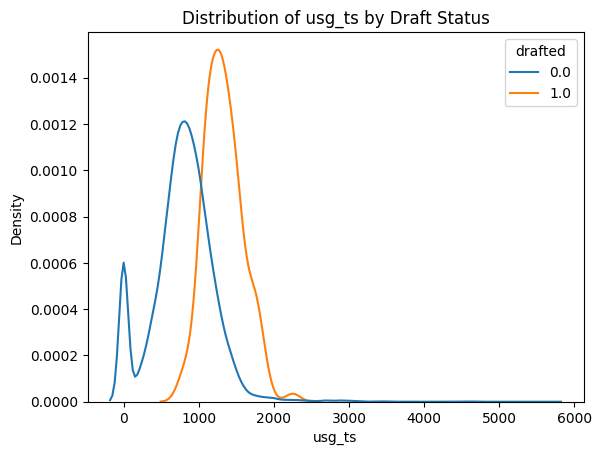

           count         mean         std      min         25%        50%  \
drafted                                                                     
0.0      14656.0   787.790515  410.069745    0.000   576.27225   804.8770   
1.0        118.0  1331.656220  254.202379  786.597  1144.05100  1303.8755   

              75%       max  
drafted                      
0.0      1024.126  5640.000  
1.0      1482.658  2251.008  


In [67]:
sns.kdeplot(data=train, x="usg_ts", hue="drafted", common_norm=False)
plt.title("Distribution of usg_ts by Draft Status")
plt.show()

print(train.groupby("drafted")["usg_ts"].describe())

In [68]:

mi = mutual_info_classif(train[["usg_ts"]], train["drafted"], random_state=26)
print("Mutual Information (usg_ts vs drafted):", mi[0])

Mutual Information (usg_ts vs drafted): 0.01262443004256475


In [69]:
# <Student to fill this section>
feature_engineering_2_explanations = """
The feature usg_ts (usage times true shooting percentage) was created to capture efficiency under workload. Validation showed that drafted players generally have higher usg_ts values than non-drafted ones, and its mutual information score with the target around 0.013. This confirms that the feature adds useful signal for distinguishing players with both high involvement and efficiency, which is crucial for draft prediction.
"""

In [70]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature "\<put_name_here\>"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [71]:
# <Student to fill this section>

In [72]:
# <Student to fill this section>
feature_engineering_n_explanations = """
Provide some explanations on why you believe it is important to create this feature and its impacts
"""

In [73]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

### F.n Fixing "\<describe_issue_here\>"

> You can add more cells related to new features in this section

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [74]:
# <Student to fill this section>

In [75]:
# 1) Use  final features + new features
final_features = features_list + ["height_in_cm", "usg_ts"]

X_all = train[final_features].copy()
y_all = train[target_name].astype(int).copy()

# 2) Initial train/validation split into 80/20

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=0.2,
    stratify=y_all,
    random_state=26
)

# 3) Print class distributions for verification

print("Train shape:", X_train.shape, " Validation shape:", X_val.shape)
print("Class distribution in train:", y_train.mean())
print("Class distribution in val:", y_val.mean())

Train shape: (11819, 41)  Validation shape: (2955, 41)
Class distribution in train: 0.007953295541077925
Class distribution in val: 0.008121827411167513


In [76]:
# <Student to fill this section>
data_splitting_explanations = """
It preserves the rare class ratio across train and validation sets, ensuring fair model evaluation.
"""

In [77]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation "\<put_name_here\>"

In [78]:
# <Student to fill this section>

In [79]:
# Identify numeric and categorical columns
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

# Numeric pipeline: median imputation + standardization
numeric_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline: most frequent imputation + one-hot encoding
categorical_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

# Combine transformers
preprocessor = ColumnTransformer([
    ("num", numeric_tf, num_cols),
    ("cat", categorical_tf, cat_cols)
])

# Fit on train, transform both
X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed = preprocessor.transform(X_val)

print("Train shape:", X_train_transformed.shape)
print("Validation shape:", X_val_transformed.shape)

Train shape: (11819, 459)
Validation shape: (2955, 459)


In [80]:
# <Student to fill this section>
data_transformation_1_explanations = """
This step ensures that all feature transformations (like imputation, scaling, encoding) are fitted only on the training set, preventing data leakage and ensuring fair model evaluation and generalization.
"""

In [81]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation "\<put_name_here\>"

In [82]:
# <Student to fill this section>

In [83]:
# <Student to fill this section>
data_transformation_2_explanations = """
Provide some explanations on why you believe it is important to perform this data transformation and its impacts
"""

In [84]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### G.4 Data Transformation "\<put_name_here\>"

In [85]:
# <Student to fill this section>

In [86]:
# <Student to fill this section>
data_transformation_3_explanations = """
Provide some explanations on why you believe it is important to perform this data transformation and its impacts
"""

In [87]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## H. Save Datasets

> Do not change this code

In [88]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(at.folder_path / 'X_train.csv', index=False)
  y_train.to_csv(at.folder_path / 'y_train.csv', index=False)

  X_val.to_csv(at.folder_path / 'X_val.csv', index=False)
  y_val.to_csv(at.folder_path / 'y_val.csv', index=False)

  X_test.to_csv(at.folder_path / 'X_test.csv', index=False)
  y_test.to_csv(at.folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

name 'at' is not defined


---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [89]:
# <Student to fill this section>

In [90]:
# <Student to fill this section>
performance_metrics_explanations = """
Given the strong class imbalance that fewer than 1% of players were drafted, accuracy is not a reliable performance measure. 

That is why metrics like AUC-ROC are more appropriate here. They evaluate how well the model distinguishes between drafted and non-drafted players regardless of imbalance. In addition, we also include precision, recall, and F1-score to provide a more complete view of the model's ability to identify the minority class effectively.
"""

In [91]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [102]:
# <Student to fill this section>

from imblearn.over_sampling import SMOTE


ImportError: cannot import name 'validate_data' from 'sklearn.utils.validation' (/Users/ashleywang/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py)

In [ ]:
# Apply SMOTE to training data 
smote = SMOTE(random_state=26)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_transformed, y_train)

print("Before SMOTE:", X_train_transformed.shape, "After SMOTE:", X_train_resampled.shape)
print("Class distribution after SMOTE:", np.bincount(y_train_resampled))

In [ ]:
# <Student to fill this section>
algorithm_selection_explanations = """
Provide some explanations on why you believe this algorithm is a good fit
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [ ]:
# <Student to fill this section>

In [162]:
# Logistic Regression 
from sklearn.linear_model import LogisticRegression


In [163]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
Logistic Regression is chosen as the baseline model due to its simplicity, efficiency, and strong interpretability. It allows us to quickly validate our feature engineering and preprocessing pipeline. As a linear model, it also sets a reliable benchmark for comparison with more complex models later.
"""

In [164]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [ ]:
# <Student to fill this section>

In [183]:
# 1. Create model with default settings

model_lr = LogisticRegression(max_iter=500, random_state=26)

# 2. Fit on training data

model_lr.fit(X_train_transformed, y_train)

# 3. Predict probabilities on validation set

val_preds = model_lr.predict_proba(X_val_transformed)[:, 1]

### J.4 Model Technical Performance

> Provide some explanations on model performance


In [ ]:
# <Student to fill this section>

In [184]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# Using threshold = 0.5 for prediction

val_labels = (val_preds >= 0.5).astype(int)

# Key performance metrics

acc = accuracy_score(y_val, val_labels)                       
prec = precision_score(y_val, val_labels, zero_division=0)    
rec = recall_score(y_val, val_labels)                         
f1 = f1_score(y_val, val_labels)                              
auc = roc_auc_score(y_val, val_preds)                        

# Results

print(f"Accuracy: {acc:.4f}")             
print(f"Precision (Drafted): {prec:.4f}") 
print(f"Recall (Drafted): {rec:.4f}")     
print(f"F1-Score (Drafted): {f1:.4f}")    
print(f"AUC-ROC: {auc:.4f}")              

Accuracy: 0.9949
Precision (Drafted): 0.8000
Recall (Drafted): 0.5000
F1-Score (Drafted): 0.6154
AUC-ROC: 0.9969


In [178]:
# <Student to fill this section>
model_performance_explanations = """
The logistic regression model achieved an accuracy of 0.9949 on the validation set. While this initially appears strong, accuracy alone can be misleading in a highly imbalanced dataset like this one, where the vast majority of players are not drafted.

More informative metrics give a clearer picture. The precision for the drafted class is 0.8000, meaning that when the model predicts a player will be drafted, it is correct 80% of the time. The recall is 0.5000, indicating that the model successfully identifies 50% of all players who were actually drafted. This suggests the model is cautious in making positive predictions, favoring precision over sensitivity.

The F1-score, which combines both precision and recall into a single metric, is 0.6154. This reflects a moderate balance between identifying true positives and avoiding false positives. Finally, the AUC-ROC score is 0.9969, indicating excellent overall ranking performance is very effective at distinguishing between drafted and undrafted players.
"""

In [179]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [ ]:
# <Student to fill this section>

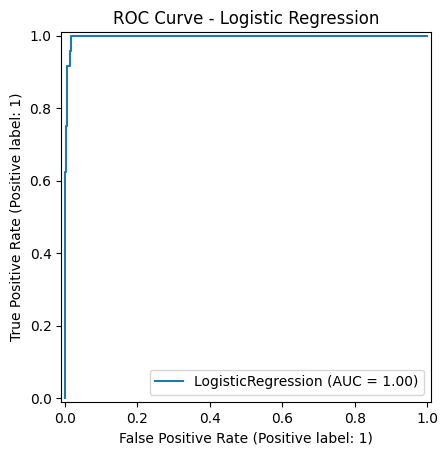

In [186]:
# ROC Curve
RocCurveDisplay.from_estimator(model_lr, X_val_transformed, y_val)
plt.title("ROC Curve - Logistic Regression")
plt.show()


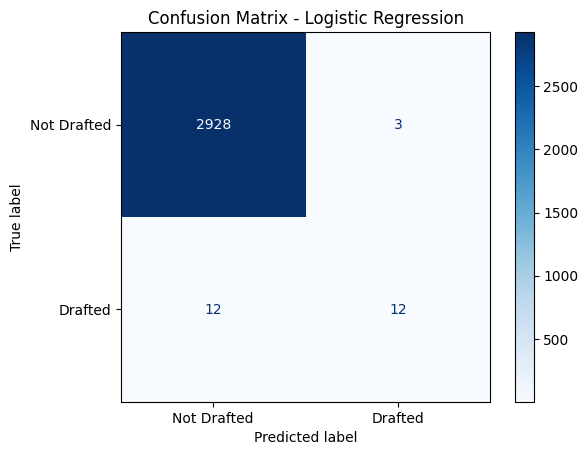

In [187]:
# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    model_lr,
    X_val_transformed,
    y_val,
    cmap="Blues",
    display_labels=["Not Drafted", "Drafted"]
)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


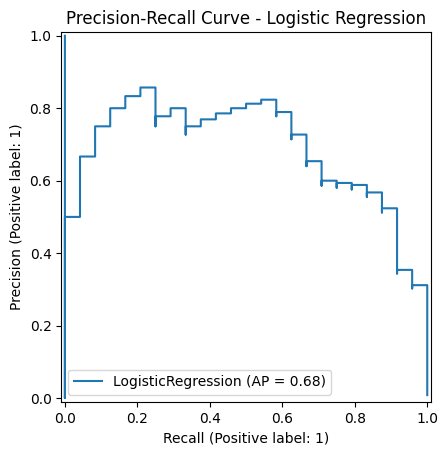

In [188]:
# Precision-Recall Curve
PrecisionRecallDisplay.from_estimator(model_lr, X_val_transformed, y_val)
plt.title("Precision-Recall Curve - Logistic Regression")
plt.show()

In [191]:
# <Student to fill this section>
business_impacts_explanations = """
The logistic regression model achieved strong technical performance on the validation set, with an AUROC of 0.9969, accuracy of 0.9949, precision of 0.8000, recall of 0.5000, and F1-score of 0.6154 for the drafted class. These results suggest that the model is highly capable of ranking players by draft likelihood, even though the dataset is extremely imbalanced.

From a business perspective, this performance indicates that the model is effective at identifying a portion of the small set of drafted players, while maintaining a relatively low false positive rate. However, the 50% recall means half of the truly drafted players are still being missed, which may lead to lost opportunities if this model were used to inform decision-making. The ROC curve and class distribution visualization further highlight the need to balance precision and recall, especially for rare but important outcomes.
"""

In [193]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [194]:
# <Student to fill this section>
experiment_outcome = ""  'Hypothesis Partially Confirmed' 

In [195]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [202]:
# <Student to fill this section>
experiment_results_explanations = """
While the logistic regression model achieved strong technical performance with AUC-ROC around 0.997, its practical effectiveness is somewhat limited by moderate recall (50%) on the positive class due to severe class imbalance.

I believe there is still some improvement can be done, especially in recall and F1. Future experiments will explore more advanced models such as XGBoost and Random Forest, which may better capture non-linear relationships in the data. 
In addition, to apply targeted resampling techniques, including SMOTE or class weight adjustments, to directly address the severe class imbalance. These next steps are expected to improve the model's ability to identify drafted players more effectively without sacrificing overall performance.

"""

In [203]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)

In [ ]:
test["height_in_cm"] = test["ht"].apply(convert_corrupted_height_to_cm)
test["usg_ts"] = test["usg"] * test["TS_per"]

# Apply same features used from Training
X_test = test[final_features].copy()

# Apply fitted preprocessing pipeline
X_test_transformed = preprocessor.transform(X_test)

# Apply Logistic Regression 
test_pred_probs = model_lr.predict_proba(X_test_transformed)[:, 1]

# Create Submission file
submission = pd.DataFrame({
    "player_id": test["player_id"],
    "drafted": test_pred_probs
})

submission.to_csv("submission_logistic_regression.csv", index=False)
print("Submission file saved: submission_logistic_regression.csv")

Submission file saved: submission_logistic_regression.csv
